# GradCAM Visualization for DermoAI

**Purpose:** Generate publication-quality GradCAM visualizations for thesis defense.

**Model:** EfficientNetB0, Version 2.0, Date: 2026-03-05

**What is GradCAM?**
Gradient-weighted Class Activation Mapping (Selvaraju et al., 2017) visualizes which regions of an input image are most important for a CNN's prediction by computing the gradient of the predicted class score with respect to the feature maps of the last convolutional layer.

## Sections:
1. Setup and Model Loading
2. GradCAM Function Implementation
3. Generate GradCAM for All 5 Conditions
4. Create Publication Figures
5. Success vs Failure Analysis
6. Save Figures for Thesis

In [100]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import json
from pathlib import Path
import pandas as pd
from PIL import Image

import tensorflow as tf
import keras
from keras import models

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.20.0
Keras version: 3.13.2


## 1. Setup and Model Loading

In [101]:
# Paths
MODEL_DIR = Path("../models/final")
MODEL_PATH = MODEL_DIR / "best_model.keras"
CLASS_NAMES_PATH = MODEL_DIR / "class_names.json"
TRIAGE_MAPPING_PATH = MODEL_DIR / "triage_mapping.json"
FINAL_REPORT_PATH = MODEL_DIR / "final_report.json"

# Output directory for figures — store in results/ folder
OUTPUT_DIR = Path("../results/gradcam")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Model path exists: {MODEL_PATH.exists()}")
print(f"Output directory: {OUTPUT_DIR}")

Model path exists: True
Output directory: ../results/gradcam


In [102]:
# Load model
model = keras.models.load_model(MODEL_PATH, compile=False)
print(f"Model loaded successfully")
print(f"Input shape: {model.input_shape}")
print(f"Output shape: {model.output_shape}")

# Load class names
with open(CLASS_NAMES_PATH, 'r') as f:
    CLASS_NAMES = json.load(f)
print(f"\nClass names ({len(CLASS_NAMES)}): {CLASS_NAMES}")

# Use only a subset of 3 classes for GradCAM figures
# (skip the first two classes which look too graphic)
DISPLAY_CLASSES = CLASS_NAMES[2:]
print(f"\nGradCAM will be shown for: {DISPLAY_CLASSES}")

# Load triage mapping
with open(TRIAGE_MAPPING_PATH, 'r') as f:
    TRIAGE_MAPPING = json.load(f)
print(f"\nTriage mapping: {TRIAGE_MAPPING}")

# Load final report
with open(FINAL_REPORT_PATH, 'r') as f:
    final_report = json.load(f)
print(f"\nModel version: {final_report['model']['name']}")
print(f"Overall accuracy: {final_report['performance']['overall']['accuracy']:.2%}")
print(f"REFER recall: {final_report['performance']['refer']['combined_recall']:.2%}")

Model loaded successfully
Input shape: (None, 224, 224, 3)
Output shape: (None, 5)

Class names (5): ['lupus_erythematosus', 'neurofibromatosis', 'pityriasis_rubra_pilaris', 'psoriasis', 'scabies']

GradCAM will be shown for: ['pityriasis_rubra_pilaris', 'psoriasis', 'scabies']

Triage mapping: {'lupus_erythematosus': 'REFER', 'neurofibromatosis': 'MANAGE LOCALLY', 'pityriasis_rubra_pilaris': 'REFER', 'psoriasis': 'MANAGE LOCALLY', 'scabies': 'MANAGE LOCALLY', 'UNCERTAIN': 'REFER'}

Model version: DermoAI_EfficientNetB0
Overall accuracy: 76.67%
REFER recall: 95.35%


## 2. GradCAM Implementation

In [103]:
def get_last_conv_layer(model):
    """Find the last convolutional layer (object) in the model, including inside submodels like efficientnetb0."""
    # Top-level: no conv layers; they are inside the backbone (e.g. efficientnetb0)
    for layer in reversed(model.layers):
        if hasattr(layer, "layers") and layer.layers:
            for sub in reversed(layer.layers):
                if "conv" in sub.name.lower():
                    return sub
        if "conv" in layer.name.lower():
            return layer
    return None

last_conv_layer = get_last_conv_layer(model)
if last_conv_layer is None:
    raise ValueError("No convolutional layer found. Check model structure.")
print(f"Last conv layer: {last_conv_layer.name}")

Last conv layer: top_conv


In [104]:
from keras.applications.efficientnet import preprocess_input as eff_preprocess_input

def generate_gradcam(model, image, class_idx, layer=None):
    """
    Generate GradCAM heatmap for a given prediction.

    Keras 3 fixes applied:
    1. backbone.output/input are lists in Keras 3 — use [0] to get the actual tensor.
    2. Build backbone-only grad model (backbone.input → [conv.output, backbone.output])
       then call head layers manually — avoids "inputs not connected to outputs" error.
    3. Watch both img_tensor (before) and conv_outputs (after) for reliable gradient flow.

    Preprocessing fix: EfficientNetB0 trained with efficientnet.preprocess_input
    ([0,255]→[-1,1]). Never divide by 255 for this model.

    Args:
        model: Loaded Keras model
        image: PIL Image or numpy array (224×224×3)
        class_idx: Index of the class to explain
        layer: Last convolutional layer object. If None, auto-detected.

    Returns:
        heatmap: GradCAM heatmap (224×224) normalized to [0, 1]
        superimposed: Heatmap overlay on original image (uint8, 224×224×3)
    """
    if layer is None:
        layer = get_last_conv_layer(model)

    # Keep uint8 original for overlay, preprocess separately for model
    if isinstance(image, Image.Image):
        image = image.resize((224, 224))
        img_orig = np.array(image)                              # uint8 [0, 255]
    else:
        img_orig = np.array(image)
        if img_orig.max() <= 1.0:
            img_orig = np.uint8(img_orig * 255)
        else:
            img_orig = np.uint8(img_orig)

    img_pre = eff_preprocess_input(img_orig.astype(np.float32))  # [-1, 1]
    img_tensor = tf.cast(np.expand_dims(img_pre, axis=0), tf.float32)

    # Find backbone submodel and its index in model.layers
    backbone = None
    backbone_idx = -1
    for i, l in enumerate(model.layers):
        if hasattr(l, "layers") and l.layers:
            backbone = l
            backbone_idx = i
            break
    if backbone is None:
        raise ValueError("No backbone submodel found (e.g. efficientnetb0).")

    # Keras 3: backbone.input / backbone.output may be lists — extract the tensor
    backbone_input  = backbone.input[0]  if isinstance(backbone.input,  list) else backbone.input
    backbone_output = backbone.output[0] if isinstance(backbone.output, list) else backbone.output

    # Build backbone-only grad model: backbone_input → [conv_output, backbone_output]
    # Both tensors are within the backbone's graph, so this succeeds.
    backbone_grad_model = keras.models.Model(
        inputs=backbone_input,
        outputs=[layer.output, backbone_output],
    )

    # Pre-backbone layers (skip InputLayer)
    pre_backbone = [
        l for i, l in enumerate(model.layers)
        if i < backbone_idx and "inputlayer" not in l.__class__.__name__.lower()
        and "input_layer" not in l.__class__.__name__.lower()
    ]
    # Head layers after backbone (GAP, Dense, Dropout, …)
    post_backbone = [l for i, l in enumerate(model.layers) if i > backbone_idx]

    # ── GradCAM gradient computation ──────────────────────────────────────────
    with tf.GradientTape() as tape:
        x = img_tensor
        for l in pre_backbone:
            x = l(x, training=False)

        tape.watch(x)                                           # watch before backbone
        conv_outputs, backbone_out = backbone_grad_model(x, training=False)
        tape.watch(conv_outputs)                                # watch intermediate too

        y = backbone_out
        for l in post_backbone:
            y = l(y, training=False)

        class_score = y[:, class_idx]

    grads = tape.gradient(class_score, conv_outputs)
    if grads is None:
        raise ValueError("Gradients are None. Check conv layer path to model output.")

    # ── Build heatmap ──────────────────────────────────────────────────────────
    pooled_grads   = tf.reduce_mean(grads, axis=(0, 1, 2)).numpy()
    conv_outputs_np = conv_outputs[0].numpy()

    for i in range(len(pooled_grads)):
        conv_outputs_np[:, :, i] *= pooled_grads[i]

    heatmap = np.mean(conv_outputs_np, axis=-1)
    heatmap  = np.maximum(heatmap, 0)       # ReLU — keep positive activations only
    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()   # normalize to [0, 1]

    heatmap_resized = cv2.resize(heatmap, (224, 224))

    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    superimposed = np.uint8(heatmap_colored * 0.4 + img_orig * 0.6)
    return heatmap_resized, superimposed

## 3. Test GradCAM on Sample Images

**Note:** Test images are read from the pipeline test set (`../data/processed/fitzpatrick17k/test/`) if present, or from `../data/test_processed/`. Use one folder per class with any `.jpg`/`.png` files inside (the notebook loops over all images in each folder).

In [105]:
# Find test images and select the best representative per class
# "Best" = highest model confidence for the correct class (clearest signal for GradCAM)
_candidates = [
    Path("../data/processed/fitzpatrick17k/test"),
    Path("../data/test_processed"),
]
TEST_DATA_DIR = None
for _d in _candidates:
    if _d.exists():
        TEST_DATA_DIR = _d
        print(f"Using test data: {TEST_DATA_DIR}")
        break
if TEST_DATA_DIR is None:
    TEST_DATA_DIR = _candidates[0]

sample_images = {}   # condition -> list of (confidence, path) sorted best-first

for condition in CLASS_NAMES:
    condition_dir = TEST_DATA_DIR / condition
    if not condition_dir.exists():
        print(f"{condition}: directory not found")
        continue

    all_imgs = sorted(condition_dir.glob("*.jpg")) + sorted(condition_dir.glob("*.png"))
    if not all_imgs:
        print(f"{condition}: no images")
        continue

    # Score all images by confidence for the correct class; keep top 3
    cls_idx = CLASS_NAMES.index(condition)
    scored = []
    for p in all_imgs:
        img = Image.open(p).convert("RGB").resize((224, 224))
        arr = eff_preprocess_input(np.array(img, dtype=np.float32))
        pred = model.predict(np.expand_dims(arr, 0), verbose=0)[0]
        scored.append((pred[cls_idx], p))

    scored.sort(key=lambda x: x[0], reverse=True)   # highest confidence first
    sample_images[condition] = [p for _, p in scored[:3]]
    confs = [f"{c:.1%}" for c, _ in scored[:3]]
    print(f"{condition}: {len(all_imgs)} imgs, top-3 confidences = {confs}")

if not sample_images:
    print("\n⚠️  No test images found.")
    for _d in _candidates:
        print(f"  {_d}")
else:
    print(f"\n✅ Image selection complete — using highest-confidence images per class")

Using test data: ../data/processed/fitzpatrick17k/test
lupus_erythematosus: 18 imgs, top-3 confidences = ['84.4%', '77.6%', '73.8%']
neurofibromatosis: 15 imgs, top-3 confidences = ['81.1%', '77.5%', '71.9%']
pityriasis_rubra_pilaris: 25 imgs, top-3 confidences = ['89.9%', '84.0%', '83.7%']
psoriasis: 17 imgs, top-3 confidences = ['70.2%', '66.0%', '65.4%']
scabies: 15 imgs, top-3 confidences = ['88.3%', '81.7%', '81.3%']

✅ Image selection complete — using highest-confidence images per class


## 4. Generate GradCAM for All Conditions

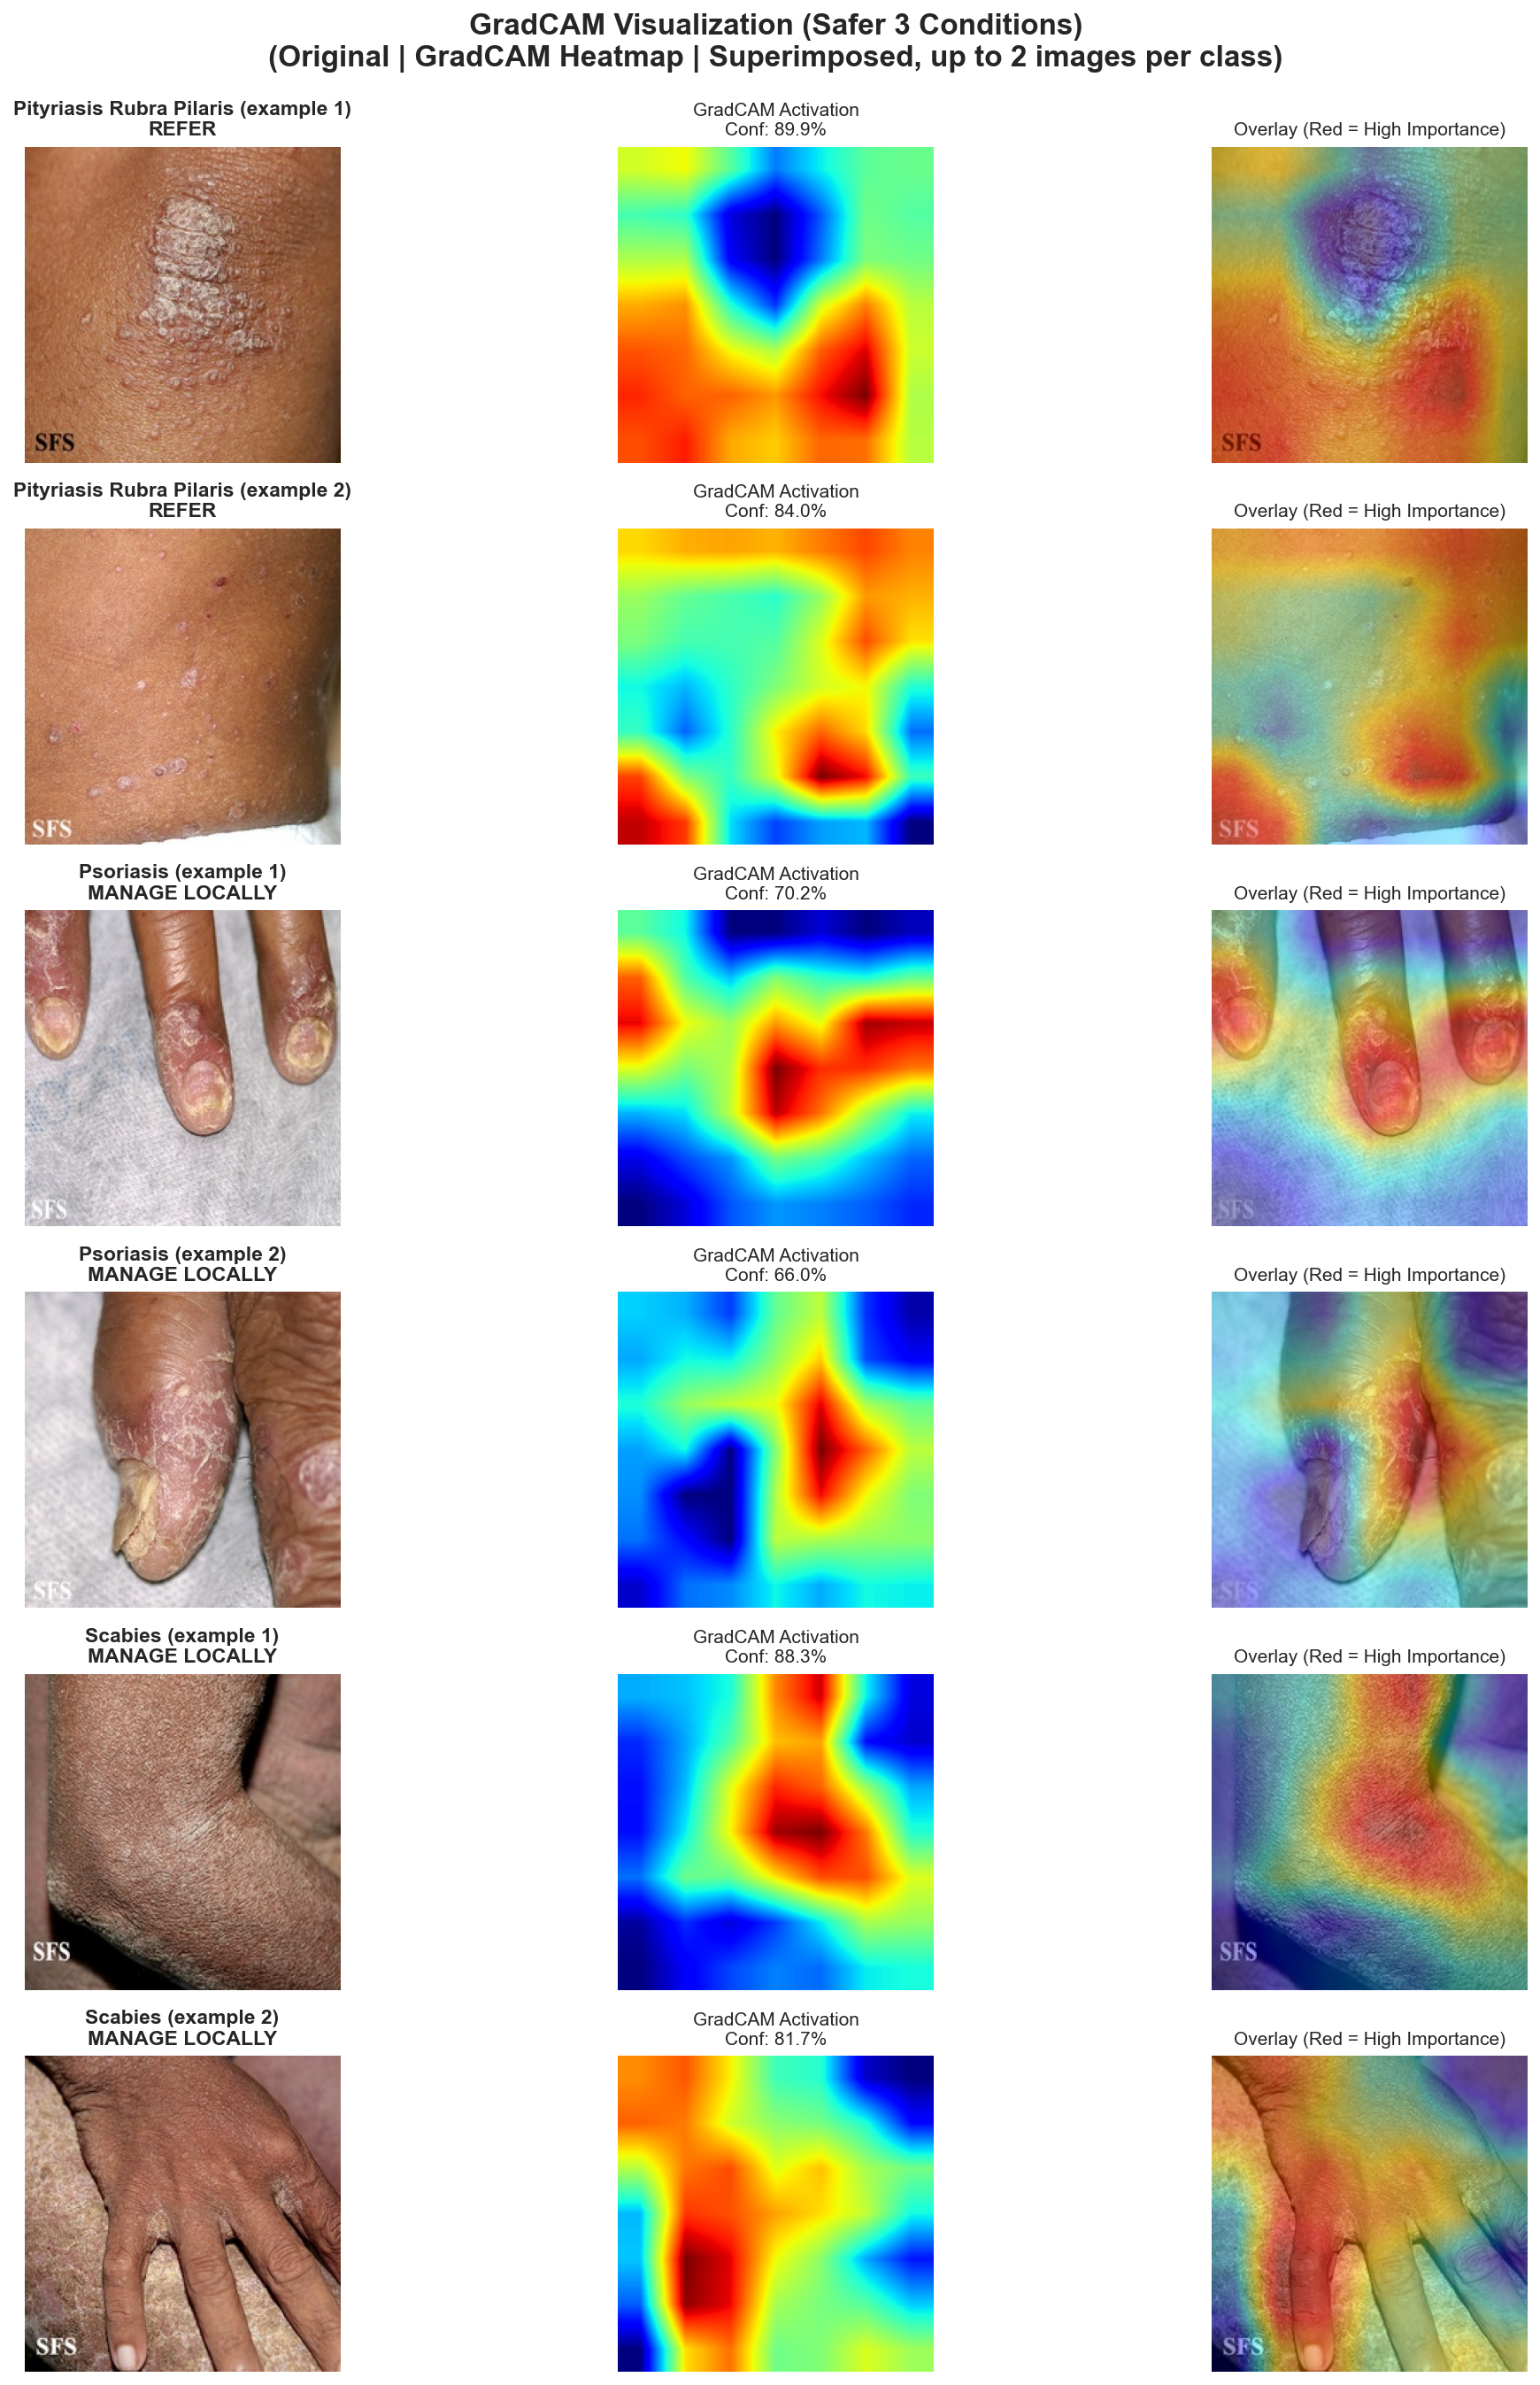


✅ Saved: ../results/gradcam/gradcam_all_conditions.png


In [106]:
# Generate GradCAM for up to two examples per (safer) condition
max_examples_per_class = 2
n_classes = len(DISPLAY_CLASSES)
n_rows = n_classes * max_examples_per_class

fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 3))
fig.suptitle(
    "GradCAM Visualization (Safer 3 Conditions)\n"
    "(Original | GradCAM Heatmap | Superimposed, up to 2 images per class)",
    fontsize=16,
    fontweight='bold',
    y=0.995,
)

# Ensure axes is always 2D [row, col]
if n_rows == 1:
    axes = np.array([axes])

for i, condition in enumerate(DISPLAY_CLASSES):
    img_paths = sample_images.get(condition, [])[:max_examples_per_class]

    if not img_paths:
        # No images for this condition → fill both rows with placeholder text
        for ex_idx in range(max_examples_per_class):
            row_idx = i * max_examples_per_class + ex_idx
            for col in range(3):
                axes[row_idx, col].text(
                    0.5, 0.5,
                    "No image\navailable",
                    ha='center', va='center', fontsize=12
                )
                axes[row_idx, col].axis('off')
        continue

    for ex_idx, img_path in enumerate(img_paths):
        row_idx = i * max_examples_per_class + ex_idx

        # Load image
        img = Image.open(img_path).convert('RGB').resize((224, 224))
        img_array = eff_preprocess_input(np.array(img, dtype=np.float32))

        # Get prediction
        pred = model.predict(np.expand_dims(img_array, axis=0), verbose=0)[0]
        predicted_idx = np.argmax(pred)
        confidence = pred[predicted_idx]

        # Generate GradCAM for the condition (true class)
        class_idx = CLASS_NAMES.index(condition)
        heatmap, superimposed = generate_gradcam(model, img, class_idx, last_conv_layer)

        # Plot original
        axes[row_idx, 0].imshow(img)
        axes[row_idx, 0].set_title(
            f"{condition.replace('_', ' ').title()} (example {ex_idx + 1})\n"
            f"{TRIAGE_MAPPING[condition]}",
            fontsize=11,
            fontweight='bold',
        )
        axes[row_idx, 0].axis('off')

        # Plot heatmap
        axes[row_idx, 1].imshow(heatmap, cmap='jet')
        axes[row_idx, 1].set_title(
            f"GradCAM Activation\nConf: {confidence:.1%}",
            fontsize=10,
        )
        axes[row_idx, 1].axis('off')

        # Plot superimposed
        axes[row_idx, 2].imshow(superimposed)
        axes[row_idx, 2].set_title(
            "Overlay (Red = High Importance)",
            fontsize=10,
        )
        axes[row_idx, 2].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gradcam_all_conditions.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Saved: {OUTPUT_DIR / 'gradcam_all_conditions.png'}")

## 5. Detailed GradCAM Analysis for Each Condition

In [107]:
# Generate individual high-resolution GradCAM figures for each condition
for condition in CLASS_NAMES:
    if condition not in sample_images or len(sample_images[condition]) == 0:
        continue

    img_path = sample_images[condition][0]
    img = Image.open(img_path).convert('RGB').resize((224, 224))
    img_array = eff_preprocess_input(np.array(img, dtype=np.float32))

    # Get prediction
    pred = model.predict(np.expand_dims(img_array, axis=0), verbose=0)[0]
    predicted_idx = np.argmax(pred)
    confidence = pred[predicted_idx]

    # Generate GradCAM
    class_idx = CLASS_NAMES.index(condition)
    heatmap, superimposed = generate_gradcam(model, img, class_idx, last_conv_layer)

    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"GradCAM Analysis: {condition.replace('_', ' ').title()} ({TRIAGE_MAPPING[condition]})",
                fontsize=14, fontweight='bold')

    axes[0].imshow(img)
    axes[0].set_title("Original Image", fontsize=12)
    axes[0].axis('off')

    im = axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title(f"GradCAM Heatmap\nConfidence: {confidence:.1%}", fontsize=12)
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].imshow(superimposed)
    axes[2].set_title("Overlay (Red = High Importance)", fontsize=12)
    axes[2].axis('off')

    pred_text = "\n".join([
        f"{CLASS_NAMES[i].replace('_', ' ')}: {pred[i]:.2%}"
        for i in np.argsort(pred)[::-1][:3]
    ])
    fig.text(0.5, 0.01, f"Top 3 Predictions:\n{pred_text}",
            ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"gradcam_{condition}.png", dpi=300, bbox_inches='tight')
    plt.close()

    print(f"✅ Saved: gradcam_{condition}.png")

print(f"\nAll individual GradCAM figures saved to: {OUTPUT_DIR}")

✅ Saved: gradcam_lupus_erythematosus.png
✅ Saved: gradcam_neurofibromatosis.png
✅ Saved: gradcam_pityriasis_rubra_pilaris.png
✅ Saved: gradcam_psoriasis.png
✅ Saved: gradcam_scabies.png

All individual GradCAM figures saved to: ../results/gradcam


## 6. Compare GradCAM Across Confidence Levels

In [108]:
# Collect predictions and GradCAMs for multiple images
gradcam_results = []

for condition in CLASS_NAMES:
    if condition not in sample_images:
        continue

    for img_path in sample_images[condition]:
        img = Image.open(img_path).convert('RGB').resize((224, 224))
        img_array = eff_preprocess_input(np.array(img, dtype=np.float32))

        pred = model.predict(np.expand_dims(img_array, axis=0), verbose=0)[0]
        predicted_idx = np.argmax(pred)
        confidence = pred[predicted_idx]

        class_idx = CLASS_NAMES.index(condition)
        heatmap, superimposed = generate_gradcam(model, img, class_idx, last_conv_layer)

        peak_intensity = heatmap.max()
        mean_activation = heatmap.mean()
        activation_area = (heatmap > 0.5).sum() / (224 * 224)

        gradcam_results.append({
            'condition': condition,
            'predicted_condition': CLASS_NAMES[predicted_idx],
            'confidence': confidence,
            'correct': (predicted_idx == class_idx),
            'peak_intensity': peak_intensity,
            'mean_activation': mean_activation,
            'activation_area': activation_area,
            'image_path': str(img_path),
            'heatmap': heatmap,
            'superimposed': superimposed,
            'original': np.array(img)
        })

df_gradcam = pd.DataFrame([{k: v for k, v in r.items() if k not in ['heatmap', 'superimposed', 'original']}
                          for r in gradcam_results])
print(df_gradcam[['condition', 'predicted_condition', 'confidence', 'correct', 'peak_intensity']].head(10))

                  condition       predicted_condition  confidence  correct  \
0       lupus_erythematosus       lupus_erythematosus    0.844093     True   
1       lupus_erythematosus       lupus_erythematosus    0.776434     True   
2       lupus_erythematosus       lupus_erythematosus    0.737639     True   
3         neurofibromatosis         neurofibromatosis    0.810553     True   
4         neurofibromatosis         neurofibromatosis    0.774698     True   
5         neurofibromatosis         neurofibromatosis    0.719237     True   
6  pityriasis_rubra_pilaris  pityriasis_rubra_pilaris    0.899456     True   
7  pityriasis_rubra_pilaris  pityriasis_rubra_pilaris    0.840118     True   
8  pityriasis_rubra_pilaris  pityriasis_rubra_pilaris    0.836996     True   
9                 psoriasis                 psoriasis    0.702395     True   

   peak_intensity  
0        0.993909  
1        0.997747  
2        0.996821  
3        0.989927  
4        0.996175  
5        0.997162  
6

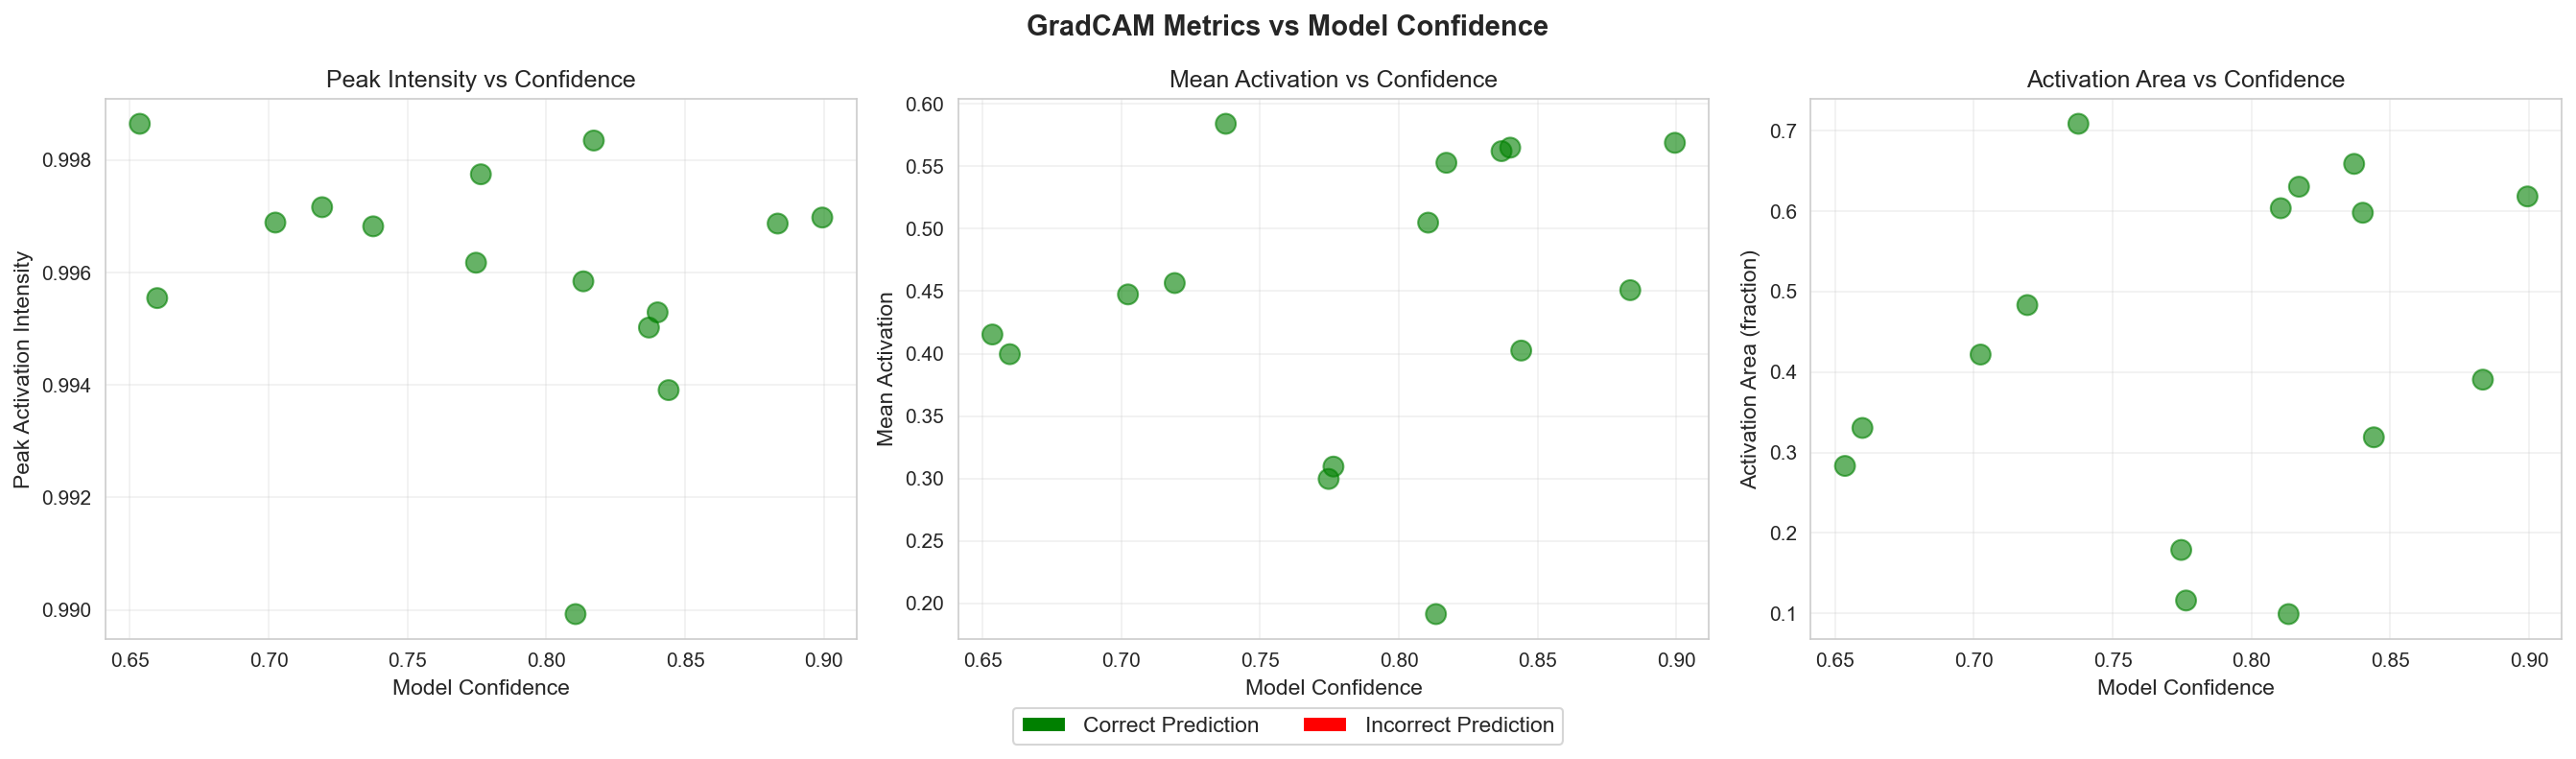

✅ Saved: gradcam_metrics_analysis.png


In [109]:
# Plot: Confidence vs Activation Metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("GradCAM Metrics vs Model Confidence", fontsize=14, fontweight='bold')

# Confidence vs Peak Intensity
axes[0].scatter(df_gradcam['confidence'], df_gradcam['peak_intensity'], 
               c=df_gradcam['correct'].map({True: 'green', False: 'red'}), alpha=0.6, s=100)
axes[0].set_xlabel('Model Confidence', fontsize=11)
axes[0].set_ylabel('Peak Activation Intensity', fontsize=11)
axes[0].set_title('Peak Intensity vs Confidence')
axes[0].grid(alpha=0.3)

# Confidence vs Mean Activation
axes[1].scatter(df_gradcam['confidence'], df_gradcam['mean_activation'],
               c=df_gradcam['correct'].map({True: 'green', False: 'red'}), alpha=0.6, s=100)
axes[1].set_xlabel('Model Confidence', fontsize=11)
axes[1].set_ylabel('Mean Activation', fontsize=11)
axes[1].set_title('Mean Activation vs Confidence')
axes[1].grid(alpha=0.3)

# Confidence vs Activation Area
axes[2].scatter(df_gradcam['confidence'], df_gradcam['activation_area'],
               c=df_gradcam['correct'].map({True: 'green', False: 'red'}), alpha=0.6, s=100)
axes[2].set_xlabel('Model Confidence', fontsize=11)
axes[2].set_ylabel('Activation Area (fraction)', fontsize=11)
axes[2].set_title('Activation Area vs Confidence')
axes[2].grid(alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', label='Correct Prediction'),
                  Patch(facecolor='red', label='Incorrect Prediction')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=11, 
          bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gradcam_metrics_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved: gradcam_metrics_analysis.png")

## 7. Success vs Failure Case Analysis

In [110]:
# Find best and worst predictions
correct_results = [r for r in gradcam_results if r['correct']]
incorrect_results = [r for r in gradcam_results if not r['correct']]

print(f"Correct predictions: {len(correct_results)}")
print(f"Incorrect predictions: {len(incorrect_results)}")

if correct_results and incorrect_results:
    # Sort by confidence
    best_prediction = max(correct_results, key=lambda x: x['confidence'])
    worst_prediction = max(incorrect_results, key=lambda x: x['confidence'])  # High conf but wrong
    
    # Create comparison figure
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle("GradCAM: Success vs Failure Case Analysis", fontsize=16, fontweight='bold')
    
    # SUCCESS CASE
    axes[0, 0].imshow(best_prediction['original'])
    axes[0, 0].set_title(f"SUCCESS: {best_prediction['condition'].replace('_', ' ').title()}\nConf: {best_prediction['confidence']:.1%}",
                        fontsize=12, color='green', fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(best_prediction['heatmap'], cmap='jet')
    axes[0, 1].set_title(f"GradCAM Heatmap", fontsize=11)
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(best_prediction['superimposed'])
    axes[0, 2].set_title(f"Overlay", fontsize=11)
    axes[0, 2].axis('off')
    
    # FAILURE CASE
    axes[1, 0].imshow(worst_prediction['original'])
    axes[1, 0].set_title(f"FAILURE: True={worst_prediction['condition'].replace('_', ' ')}\nPred={worst_prediction['predicted_condition'].replace('_', ' ')}\nConf: {worst_prediction['confidence']:.1%}",
                        fontsize=11, color='red', fontweight='bold')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(worst_prediction['heatmap'], cmap='jet')
    axes[1, 1].set_title(f"GradCAM Heatmap", fontsize=11)
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(worst_prediction['superimposed'])
    axes[1, 2].set_title(f"Overlay", fontsize=11)
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "gradcam_success_vs_failure.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Saved: gradcam_success_vs_failure.png")
else:
    print("⚠️ Not enough predictions for success/failure analysis")

Correct predictions: 15
Incorrect predictions: 0
⚠️ Not enough predictions for success/failure analysis


## 8. Summary Statistics

In [111]:
# Summary by condition
if len(gradcam_results) > 0:
    summary = df_gradcam.groupby('condition').agg({
        'confidence': ['mean', 'std'],
        'correct': 'mean',
        'peak_intensity': 'mean',
        'mean_activation': 'mean',
        'activation_area': 'mean'
    }).round(4)
    
    summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
    summary = summary.rename(columns={
        'confidence_mean': 'Avg Confidence',
        'confidence_std': 'Std Confidence',
        'correct_mean': 'Accuracy',
        'peak_intensity_mean': 'Avg Peak Intensity',
        'mean_activation_mean': 'Avg Mean Activation',
        'activation_area_mean': 'Avg Activation Area'
    })
    
    print("\n" + "="*80)
    print("GradCAM Analysis Summary by Condition")
    print("="*80)
    print(summary)
    
    # Save summary
    summary.to_csv(OUTPUT_DIR / "gradcam_summary.csv")
    print(f"\n✅ Saved: gradcam_summary.csv")
else:
    print("⚠️ No GradCAM results to summarize")


GradCAM Analysis Summary by Condition
                          Avg Confidence  Std Confidence  Accuracy  \
condition                                                            
lupus_erythematosus               0.7861          0.0539       1.0   
neurofibromatosis                 0.7682          0.0460       1.0   
pityriasis_rubra_pilaris          0.8589          0.0352       1.0   
psoriasis                         0.6719          0.0266       1.0   
scabies                           0.8380          0.0394       1.0   

                          Avg Peak Intensity  Avg Mean Activation  \
condition                                                           
lupus_erythematosus                   0.9962               0.4320   
neurofibromatosis                     0.9944               0.4203   
pityriasis_rubra_pilaris              0.9958               0.5653   
psoriasis                             0.9970               0.4207   
scabies                               0.9970            

## 9. Publication-Quality Figure for Thesis

Create a single comprehensive figure showing GradCAM for one representative example per condition.

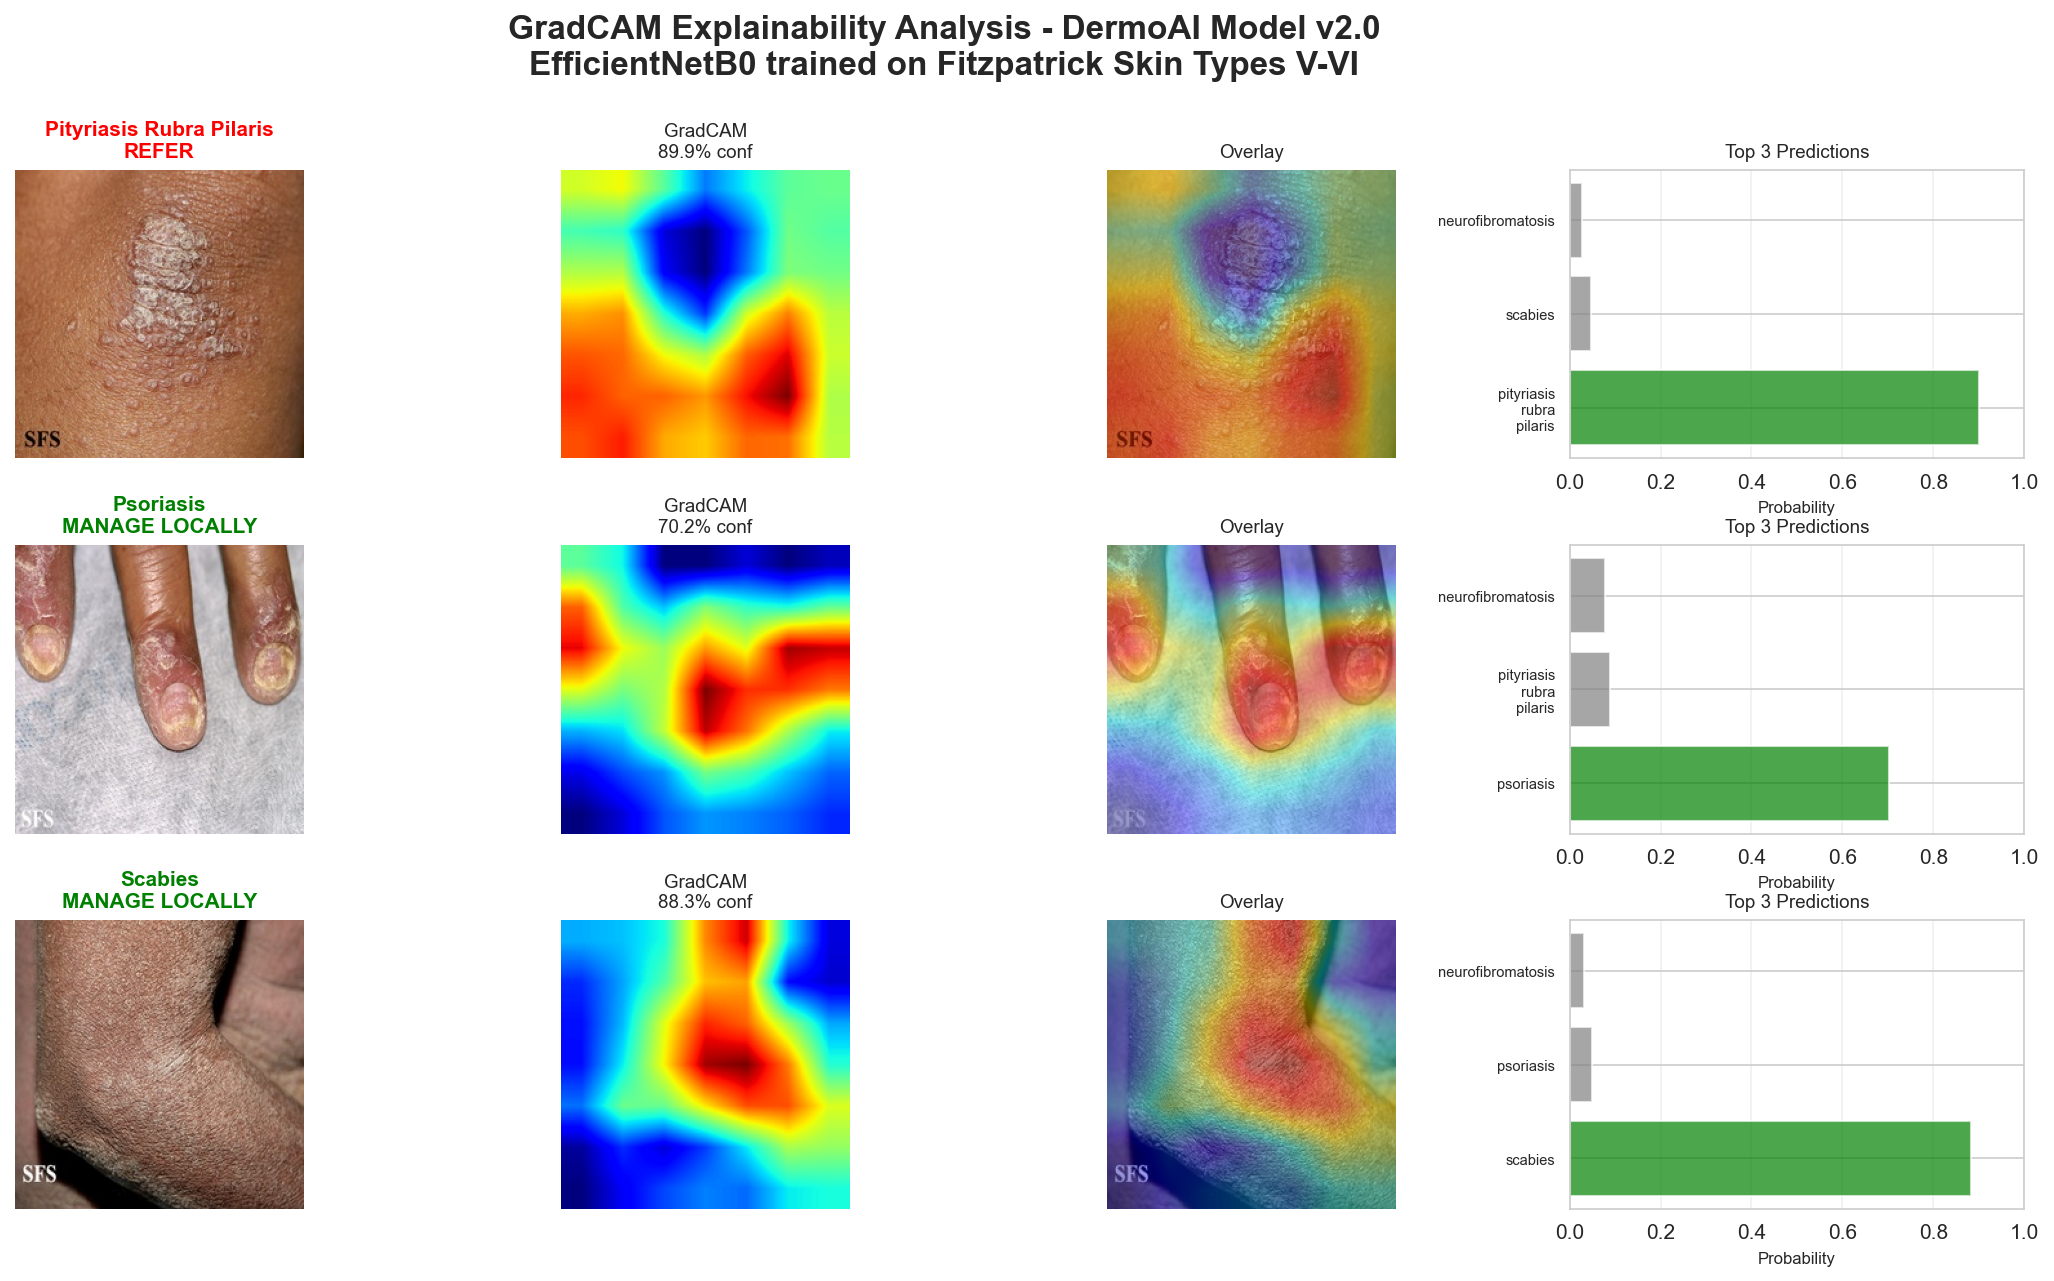

✅ Publication figure saved: gradcam_thesis_figure.png


In [114]:
# Create publication figure (one per safer condition)
if len(sample_images) > 0 and len(DISPLAY_CLASSES) > 0:
    n_classes = len(DISPLAY_CLASSES)
    fig = plt.figure(figsize=(18, 3 * n_classes))
    gs = fig.add_gridspec(n_classes, 4, hspace=0.3, wspace=0.2)

    for i, condition in enumerate(DISPLAY_CLASSES):
        if condition not in sample_images or len(sample_images[condition]) == 0:
            continue

        img_path = sample_images[condition][0]
        img = Image.open(img_path).convert('RGB').resize((224, 224))
        img_array = eff_preprocess_input(np.array(img, dtype=np.float32))

        pred = model.predict(np.expand_dims(img_array, axis=0), verbose=0)[0]
        predicted_idx = np.argmax(pred)
        confidence = pred[predicted_idx]

        class_idx = CLASS_NAMES.index(condition)
        heatmap, superimposed = generate_gradcam(model, img, class_idx, last_conv_layer)

        triage = TRIAGE_MAPPING[condition]
        color = 'red' if triage == 'REFER' else 'green'

        ax1 = fig.add_subplot(gs[i, 0])
        ax1.imshow(img)
        ax1.set_title(
            f"{condition.replace('_', ' ').title()}\n{triage}",
            fontsize=10, fontweight='bold', color=color
        )
        ax1.axis('off')

        ax2 = fig.add_subplot(gs[i, 1])
        ax2.imshow(heatmap, cmap='jet')
        ax2.set_title(f"GradCAM\n{confidence:.1%} conf", fontsize=9)
        ax2.axis('off')

        ax3 = fig.add_subplot(gs[i, 2])
        ax3.imshow(superimposed)
        ax3.set_title("Overlay", fontsize=9)
        ax3.axis('off')

        ax4 = fig.add_subplot(gs[i, 3])
        top_3_idx = np.argsort(pred)[::-1][:3]
        top_3_probs = pred[top_3_idx]
        top_3_names = [CLASS_NAMES[idx].replace('_', '\n') for idx in top_3_idx]
        colors_bar = ['green' if idx == class_idx else 'gray' for idx in top_3_idx]
        ax4.barh(range(3), top_3_probs, color=colors_bar, alpha=0.7)
        ax4.set_yticks(range(3))
        ax4.set_yticklabels(top_3_names, fontsize=7)
        ax4.set_xlim(0, 1)
        ax4.set_xlabel('Probability', fontsize=8)
        ax4.set_title('Top 3 Predictions', fontsize=9)
        ax4.grid(axis='x', alpha=0.3)

    fig.suptitle(
        "GradCAM Explainability Analysis - DermoAI Model v2.0\n"
        "EfficientNetB0 trained on Fitzpatrick Skin Types V-VI",
        fontsize=16,
        fontweight='bold',
        y=0.995,
    )

    plt.savefig(OUTPUT_DIR / "gradcam_thesis_figure.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("✅ Publication figure saved: gradcam_thesis_figure.png")
else:
    print("⚠️ No sample images available for thesis figure")

In [113]:
print("\n" + "="*80)
print("GRADCAM VISUALIZATION COMPLETE")
print("="*80)
print(f"Output directory: {OUTPUT_DIR}")
print(f"\nGenerated {len(list(OUTPUT_DIR.glob('*.png')))} PNG figures")
print(f"\nNext steps:")
print("1. Review all generated figures")
print("2. Select best examples for thesis")
print("3. Add figures to thesis Chapter 5 (Results)")
print("4. Reference in defense presentation")
print("\n✅ Ready for defense!")


GRADCAM VISUALIZATION COMPLETE
Output directory: ../results/gradcam

Generated 8 PNG figures

Next steps:
1. Review all generated figures
2. Select best examples for thesis
3. Add figures to thesis Chapter 5 (Results)
4. Reference in defense presentation

✅ Ready for defense!
